<a href="https://colab.research.google.com/github/Malika-code4/Lab-3/blob/main/lab_3_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


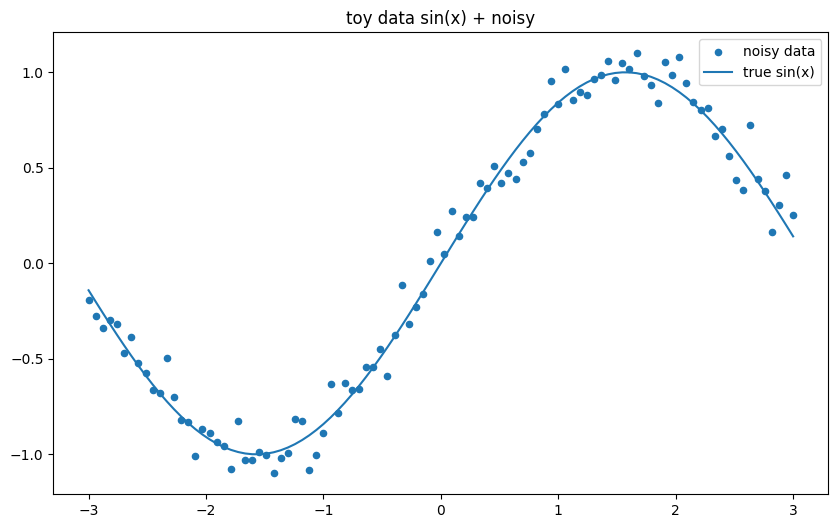

initial w: 0.24835707650561634 initial b: -0.06913215058559233
final w: 0.34026294599880846 final b: 0.011232621106270265
final loss 0.17443991545735904


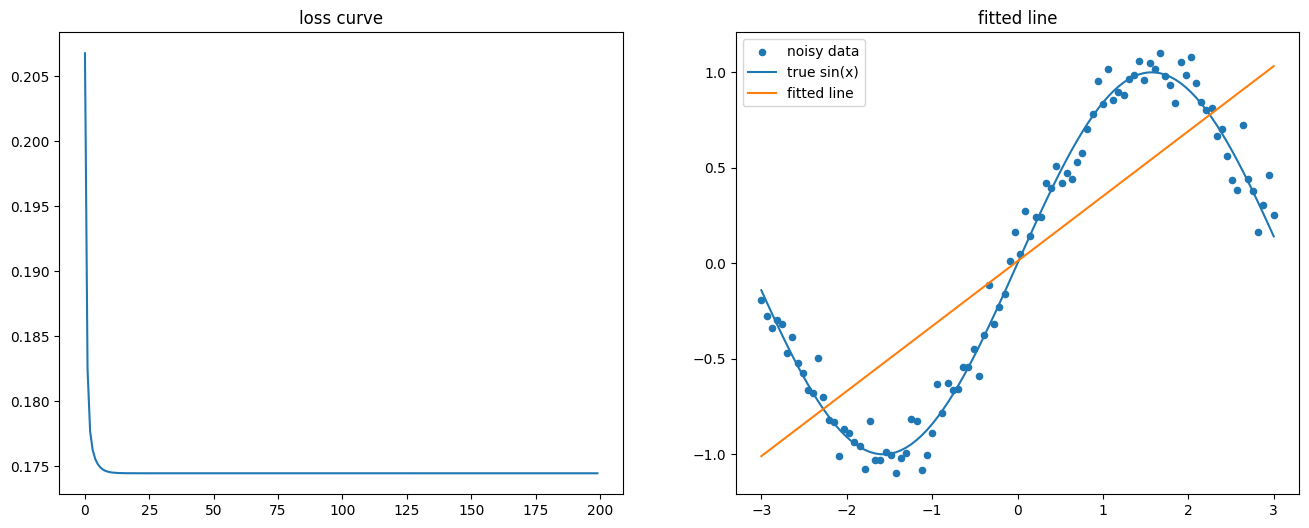

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)
plt.figure(figsize=(10,6))
plt.scatter(x, y, s=20, label="noisy data")
plt.plot(x, np.sin(x), label="true sin(x)")
plt.legend()
plt.title("toy data sin(x) + noisy")
plt.show()

# TODO: Initialise w and b to small random values.
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5
print("initial w:", w, "initial b:", b)
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.1
steps = 200
losses = []
for step in range(steps):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw     = np.mean(2 * (y_hat - y) * x)
    db    = np.mean(2 * (y_hat - y))

    w    -= lr * dw
    b    -= lr * db

print("final w:", w, "final b:", b)
print("final loss", loss)
# TODO: Plot (a) the loss curve over the 200 steps, and
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(losses)
axes[0].set_title("loss curve")
axes[1].scatter(x, y, s=20, label="noisy data")
axes[1].plot(x, np.sin(x), label="true sin(x)")
axes[1].plot(x, w * x + b, label="fitted line")
axes[1].legend()
axes[1].set_title("fitted line")
plt.show()

#             (b) the data with the fitted line on top.

In [ ]:
# TODO: Initialise parameters
np.random.seed(RANDOM_STATE)
n_hidden = 8
w1 = np.random.randn(1, n_hidden) * 0.5
b1 = np.random.randn(n_hidden) * 0.5
w2 = np.random.randn(n_hidden, 1) * 0.5
b2 = np.random.randn(1) * 0.5
x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
lr = 0.05
steps = 3000
losses_hidden = []
for step in range(steps):
    # Forward pass
    z1 = x_col @ w1 + b1
    h = np.tanh(z1)
    z2 = h @ w2 + b2
    y_hat = z2
    loss = np.mean((y_hat - y_col) ** 2)
    losses_hidden.append(loss)

    # Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    d_z2 = d_yhat

    # Gradients for W2 and b2
    dW2 = h.T @ d_z2
    db2 = d_z2.sum(axis=0)

    # Propagate gradients back to h
    dh = d_z2 @ w2.T

    # Propagate gradients back to z1 (derivative of tanh)
    dz1 = dh * (1 - h ** 2)

    # Gradients for W1 and b1
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update all parameters with learning rate lr
    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
print("Final loss (with tanh):", losses_hidden[-1])

Final loss (with tanh): 0.009438588120092281


In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.


In [ ]:
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.


In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.


In [ ]:
# TODO: Load your best configuration's weights; model.eval().
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
best_model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=len(class_names))
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model = best_model.to(DEVICE)
best_model.eval()
# TODO: Report test ACCURACY and MACRO-F1
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
test_acc =accuracy_score(all_labels, all_preds)
test_f1_macro = f1_score(all_labels, all_preds, average = "macro")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test macro-F1: {test_f1_macro:.3f}")
print("\nfull classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
# TODO: Confusion matrix for the test set with the 7 class names
fig, ax = plt.subplots(figsize=(10, 10))
cm = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, xticks_rotation = 46 cmap="Blues", ax=ax)
plt.titlle("neural network - test set confision matrix")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
import time
start_time = time.time()
nn_train_time = None
nn_param_count = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
comparison_df = pd.DataFrame({
    "model":["lab"]
    "text_acc":[lab_train_acc],
    "val_acc":[lab_val_acc],
    "test_acc":[lab_test_acc],
})

NameError: name 'input_dim' is not defined